In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from VAE_EoS import Sampling
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from toolbox import pickle_load
from pathlib import Path
import joblib

In [2]:
latent_dim_variational=1
eta=0.01
kappa=5

dir_name="data_model_picked/skyrme"
outdir = dir_name+'/'+ f'latent{latent_dim_variational}_eta{eta:.2g}_kappa{kappa:.2g}' 

Mmax_plot=[1.9,2.,2.1,2.2,2.3]
R14_fixed=[12.7]*len(Mmax_plot)
MmaxR14_plot=[2.1,12.7]
R14_plot = MmaxR14_plot[1]+np.linspace(-1.2, 0.8, 6)

In [3]:
#load the autoencoder network

encoder= keras.models.load_model(outdir+"/encoder.keras")
decoder= keras.models.load_model(outdir+"/decoder.keras")
scaler_X=joblib.load(outdir+"/X_scaler.joblib")
scaler_y=joblib.load(outdir+"/y_scaler.joblib")

# X_test_scaled  = scaler_X.transform(X_test)
# y_test_obs_scaled  = scaler_y.transform(y_test_obs)
# mu_k_test, mu_u_test, log_var_u_test, z_test = encoder(X_test_scaled, training=False)
# y_obs = scaler_y.inverse_transform(mu_k_test)
# X_test_reconstructed = decoder(tf.concat([mu_k_test, mu_u_test], axis=1))


In [5]:
from skyrme import EDF_Skyrme

EDF_sly4=[[-2488,486.82,-546.3,13777,123],[0.834,-0.344,-1,1.354,1/6]]
skyrme_sly4=EDF_Skyrme(EDF_sly4)

EDF_SkI4=[[-1855.83, 473.829, 1006.86, 9703.61,183.097],[0.4051,  -2.8891, -1.3252,1.1452, 0.25]]#b4=183.097,b4'=-180.351
skyrme_SkI4=EDF_Skyrme(EDF_SkI4)

edf_list=[skyrme_sly4,skyrme_SkI4]
name_list=['SLy4','SkI4']


In [6]:
def Calculation_eos_array(edf,other_args):
    for nB_init in [0.05,0.03,0.07,0.01,0.09]:
        try:
            crust_core_nB=edf.crust_core_nB(nB_init=nB_init)
            break
        except:
            crust_core_nB=0
    #print(crust_core_nB)

    crust_core_Yp=edf.eosBeta_eq_from(crust_core_nB)
    # eos_array=[]
    eos_array_tot=[]
    Yp=crust_core_Yp
    Yp_prev=Yp
    for nB in np.linspace(crust_core_nB,1.5,200):
        #print(nB,Yp)
        Yp_init=2*Yp-Yp_prev
        Yp_prev=Yp
        if(Yp_init>1e-6):
            for ratio in [1,0.5,2,0.1,10]:
                try:
                    Yp=edf.eosBeta_eq_from(nB,Yp_init=Yp_init)
                    break
                except:
                    Yp=0
        else:
            Yp=0
        # eos_array.append(edf.eos_array_from_n(Yp*nB, (1-Yp)*nB))
        eos_array_tot.append(np.concatenate((edf.eos_array_tot_from_n(Yp*nB, (1-Yp)*nB),[Yp])))
    return np.array(eos_array_tot).transpose()

eos_array_list=[]
for edf in edf_list:
    eos_array_list.append(Calculation_eos_array(edf,[]))
eos_array_list=np.array(eos_array_list)

In [10]:
from eos_class import EOS_interpolation,quality_control_none,EOS_SLY4,EOS_hybrid1
sly4=EOS_SLY4()
eos_list=[]
#check_logic=[]
for eos_array_tot_i in eos_array_list:
    eos_array_tot_i=eos_array_tot_i[:,eos_array_tot_i[3]>1e-5]
    eos=EOS_hybrid1(eos_array_tot_i[2,0],sly4,EOS_interpolation(0.16,eos_array_tot_i[:3],quality_control_f=quality_control_none),allow_unstable=True)
    eos_list.append(eos)
#     plt.loglog(eos_array_tot_i[0,0],eos_array_tot_i[2,0],'o')
#     plt.loglog(sly4.eos_array[0],sly4.eos_array[2],'k')
#     plt.loglog(eos_list[-1].eosBaryonDensity(np.linspace(0.000001,1,100)),np.linspace(0.000001,1,100))
#     #check_logic.append(eos_list[-1].eosBaryonDensity(1e-6)>1e-3)
# #check_logic=np.array(check_logic)
# plt.xlim(0.00001,0.5)
# plt.ylim(0.000001,1)
eos_list=np.array(eos_list)

def f(lnp,eps_lnn,cs2):
    eps,lnn=eps_lnn
    p=np.exp(lnp)
    deps_dlnp=p/cs2(lnp)
    dlnn_dlnp=deps_dlnp/(eps+p)
    return np.array([deps_dlnp,dlnn_dlnp])
from scipy import interpolate
from tov_f import lsoda_ode_array
from Hadronic_calculation import Calculation_maxmass
#result_maxmass=main_parallel_unsave(Calculation_maxmass,eos_list)
result_maxmass=[Calculation_maxmass(eos) for eos in eos_list]
result_maxmass=np.array(result_maxmass)

data_boundary=[]
data_eos_array=[]
data_cs2=[]
data_107=[]
for eos,maxmass in zip(eos_list,result_maxmass):
    pc_max,mass_max,cs2_max=maxmass
    data_boundary.append(np.concatenate((eos.eos_high.eos_array[:,0],[eos.eosBaryonDensity(pc_max),eos.eosDensity(pc_max),pc_max])))
    p_array=np.exp(np.linspace(np.log(eos.eos_high.eos_array[2,0]),np.log(pc_max),101))
    data_eos_array.append([eos.eos_high.eosBaryonDensity(p_array),eos.eos_high.eosDensity(p_array),p_array])
    data_cs2.append(eos.eos_high.eosCs2(p_array))
    data_107.append(np.concatenate((data_cs2[-1],data_boundary[-1])))


In [11]:
def f(lnp,eps_lnn,cs2):
    eps,lnn=eps_lnn
    p=np.exp(lnp)
    deps_dlnp=p/cs2(lnp)
    dlnn_dlnp=deps_dlnp/(eps+p)
    return np.array([deps_dlnp,dlnn_dlnp])

from scipy import interpolate
from tov_f import lsoda_ode_array
from eos_class import EOS_SLY4,EOS_interpolation
eos_sly4=EOS_SLY4()

eos_data=data_107[0]

lnp_array=np.linspace(np.log(eos_data[103]),np.log(eos_data[106]),101)
cs2_int=interpolate.UnivariateSpline(lnp_array,eos_data[:101], k=2,s=0)
sol=lsoda_ode_array(f,1e-10,[eos_data[102],np.log(eos_data[101])],np.log(eos_data[103]),lnp_array,cs2_int,method='lsoda')
eos_array=np.array([np.exp(sol[:,1]),sol[:,0],np.exp(lnp_array)])

eos_array_complete=np.concatenate((eos_sly4.eos_array[:,np.min(eos_sly4.eos_array<0.9*eos_array[:,[0]],axis=0)],eos_array),axis=1)
eos=EOS_interpolation(0.16,eos_array_complete)

#print(MassRadius(100,1e-8, Preset_rtol,'MR',eos))
#plt.plot(eos_array_complete[0],eos_array_complete[2])

from FindMaxmass import Maxmass
from MassRadius_hadronic import MassRadius
from Find_OfMass import Properity_ofmass
Preset_Pressure_final, Preset_rtol=1e-9,1e-5
#MassRadius(eos_data[-1],Preset_Pressure_final, Preset_rtol,'MR',eos)
print("Maxmass=",Maxmass(Preset_Pressure_final, Preset_rtol, eos)[1:3]) #compare with eos_data[-1],latent_mean[0,0])
print("R_1.4=",Properity_ofmass(1.4,10,eos_data[-1],MassRadius,Preset_Pressure_final,Preset_rtol,1,eos)[2]/1e3) # compare with,latent_mean[0,1])

Maxmass= [857.633056640625, 2.0581095816198998]
R_1.4= 11.74888008703486


[[ 2.05850077 11.74416264]] tf.Tensor([[0.5596764]], shape=(1, 1), dtype=float32) [[0.04889312]]



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done  46 tasks      | elapsed:    0.6s
[Parallel(n_jobs=9)]: Done 346 tasks      | elapsed:    4.1s
[Parallel(n_jobs=9)]: Done 846 tasks      | elapsed:    9.9s
[Parallel(n_jobs=9)]: Done 983 out of 1000 | elapsed:   11.4s remaining:    0.2s
[Parallel(n_jobs=9)]: Done 1000 out of 1000 | elapsed:   11.6s finished


[[ 2.19458823 12.59683071]] tf.Tensor([[-0.35302764]], shape=(1, 1), dtype=float32) [[0.01294093]]



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=9)]: Done 346 tasks      | elapsed:    4.1s
[Parallel(n_jobs=9)]: Done 846 tasks      | elapsed:   10.0s
[Parallel(n_jobs=9)]: Done 983 out of 1000 | elapsed:   11.6s remaining:    0.2s
[Parallel(n_jobs=9)]: Done 1000 out of 1000 | elapsed:   11.7s finished


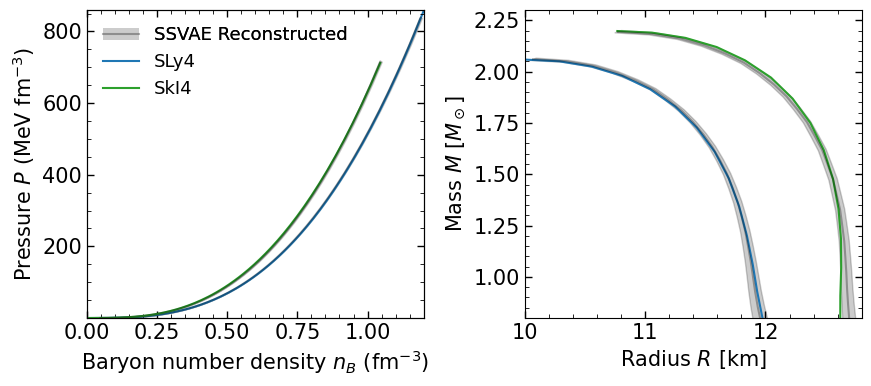

EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_cla

In [169]:
from matplotlib_rc import *

from eos_class import EOS_SLY4, EOS_interpolation
eos_sly4 = EOS_SLY4()

fig, (ax_eos, ax_mr) = plt.subplots(1, 2, sharey=False,figsize=(10,4))
plt.subplots_adjust(wspace=0.3)

# ax_eos.plot(
#     eos_sly4.eos_array[0], eos_sly4.eos_array[2],
#     lw=2, ls="--", color="b", label=r"SLy4"
# )
#ax_eos.set_yscale('log')
#ax_eos.set_xscale('log')
p_min_plot=0.1
p_max_plot=860
ax_eos.set_xlim(0,1.2)
ax_eos.set_ylim(p_min_plot,p_max_plot)
ax_mr.set_xlim(10,12.8)
ax_mr.set_ylim(0.8,2.3)


eos_sly4_interp = EOS_interpolation(0.16, eos_sly4.eos_array)
pc_vals_sly4 = np.exp(np.linspace(np.log(10), np.log(855), 20))

# MR_sly4 = []
# for pc in pc_vals_sly4:
#     MR_sly4.append(MassRadius(pc, Preset_Pressure_final, Preset_rtol, "MR", eos_sly4_interp))
# MR_sly4 = np.array(MR_sly4).T

# ax_mr.plot(
#     MR_sly4[1]/1000.0, MR_sly4[0],
#     lw=2.2, ls="--", color="b")

def Calculation_MR(eos_data,other_args=[]):
    lnp_array=np.linspace(np.log(eos_data[103]),np.log(eos_data[106]),101)
    cs2_int=interpolate.UnivariateSpline(lnp_array,eos_data[:101], k=2,s=0)
    sol=lsoda_ode_array(f,1e-10,[eos_data[102],np.log(eos_data[101])],np.log(eos_data[103]),lnp_array,cs2_int,method='lsoda')
    eos_array=np.array([np.exp(sol[:,1]),sol[:,0],np.exp(lnp_array)])

    eos_array_complete=np.concatenate((eos_sly4.eos_array[:,np.min(eos_sly4.eos_array<0.9*eos_array[:,[0]],axis=0)],eos_array),axis=1)
    eos=EOS_interpolation(0.16,eos_array_complete)

    MR_data = []
    for pc in np.exp(np.linspace(np.log(5), np.log(eos_data[-1]), 20)):
        MR_data.append(MassRadius(pc, Preset_Pressure_final, Preset_rtol, "MR", eos))
    MR_data = np.array(MR_data).T

    return eos_array_complete,MR_data

for eos_data,curve_color in zip(data_107,['tab:blue','tab:green','tab:red']):
    eos_array_complete,MR_data = Calculation_MR(eos_data)

    line_mr, = ax_mr.plot(MR_data[1]/1000.0, MR_data[0], lw=1.5, color=curve_color)
    ax_eos.plot(eos_array_complete[0], eos_array_complete[2], lw=1.5, color=curve_color)

    eos_data_reconstructed_list=[]
    for i in range(1000):
        mu_k_data, mu_u_data, log_var_u_data, z_data = encoder(scaler_X.transform([np.log(eos_data)]), training=False)
        mu_k_data_random=scaler_y.transform(scaler_y.inverse_transform(mu_k_data)*(np.random.normal(0,0.0014,2)+1))
        #eos_data_reconstructed = decoder(tf.concat([mu_k_data, mu_u_data], axis=1))
        eos_data_reconstructed = np.exp(decoder(tf.concat([mu_k_data_random, np.array(z_data[:,2])[:,np.newaxis]], axis=1))[0])
        eos_data_reconstructed_list.append(eos_data_reconstructed)
    eos_data_reconstructed=np.array(eos_data_reconstructed_list)
    print(scaler_y.inverse_transform(mu_k_data),mu_u_data,np.exp(log_var_u_data))
    print()
    result=(main_parallel_unsave(Calculation_MR,eos_data_reconstructed))
    MR_complete_list=np.array([result_i[1] for result_i in result])

    from scipy.interpolate import interp1d
    beta_max_min=np.infty
    beta_min_max=0
    interp_list=[]
    for MR_i in MR_complete_list:
        beta_max_min=min((MR_i[0]/MR_i[1]*1000).max(),beta_max_min)
        beta_min_max=max((MR_i[0]/MR_i[1]*1000).min(),beta_min_max)
        interp_list.append(interp1d(MR_i[0]/MR_i[1]*1000,MR_i[0]+MR_i[1]/1000))
        #plt.plot(MR_i[1]/1000,MR_i[0])
    beta_plot=np.linspace(beta_min_max,beta_max_min,30)
    interp_MR=[]
    for interp_f in interp_list:
        interp_MR.append(interp_f(beta_plot))
    interp_MR=np.array(interp_MR)
    interp_MR_mean=interp_MR.mean(axis=0)
    interp_MR_std=interp_MR.std(axis=0)
    ax_mr.plot(interp_MR_mean/(beta_plot+1),interp_MR_mean*beta_plot/(beta_plot+1),'k',alpha=0.3)
    
    R=np.concatenate((interp_MR_mean+2*interp_MR_std,(interp_MR_mean-2*interp_MR_std)[::-1]))/(np.concatenate((beta_plot,beta_plot[::-1]))+1)
    M=np.concatenate((interp_MR_mean+2*interp_MR_std,(interp_MR_mean-2*interp_MR_std)[::-1]))/(1+1/np.concatenate((beta_plot,beta_plot[::-1])))
    ax_mr.fill(R,M, color="k", alpha=0.2)

    interp_list=[]
    p_min_max=[p_min_plot,np.infty]
    for result_i in result:
        p_min_max=[max(p_min_max[0],result_i[0][2].min()),min(p_min_max[1],result_i[0][2].max())]
        interp_list.append(interp1d(np.log(result_i[0][2]),np.log(result_i[0][0])))
    lnp_plot=np.linspace(np.log(p_min_max[0]),np.log(p_min_max[1]),100)
    interp_nB=[]
    for interp_f in interp_list:
        interp_nB.append(interp_f(lnp_plot))
    interp_nB=np.array(interp_nB)
    interp_nB_mean=interp_nB.mean(axis=0)
    interp_nB_std =interp_nB.std(axis=0)
    ax_eos.plot(np.exp(interp_nB_mean),np.exp(lnp_plot),'k',alpha=0.3)

    ax_eos.fill_betweenx(np.exp(lnp_plot),np.exp(interp_nB_mean-2*interp_nB_std),np.exp(interp_nB_mean+2*interp_nB_std), color="k", alpha=0.2)

ax_eos.set_xlabel(r"Baryon number density $n_B$ (fm$^{-3}$)",fontsize=15)
ax_eos.set_ylabel(r"Pressure $P$ (MeV fm$^{-3}$)",fontsize=15)
ax_mr.set_xlabel(r"Radius $R$ [km]",fontsize=15)
ax_mr.set_ylabel(r"Mass $M$ [$M_\odot$]",fontsize=15)
ax_eos.plot([],[],'k',alpha=0.3,label='SSVAE Reconstructed')
[ax_eos.plot([],[],label=label, color = color) for  label,color in zip(name_list,['tab:blue','tab:green'])]
ax_eos.legend(frameon=False,fontsize=13)
ax_eos_twin=ax_eos.twinx()
ax_eos_twin.fill([],[],'k',alpha=0.2,label='SSVAE Reconstructed')
ax_eos_twin.legend(frameon=False,fontsize=13,loc=2)
ax_eos_twin.set_ylim(p_min_plot,p_max_plot)
ax_eos_twin.set_yticklabels('')

plt.savefig('./figures/Skyrme_Reconstruct.pdf',bbox_inches = 'tight',format='pdf')#, dpi=dpi)
